In [1]:
# BiLSTM-based Intrusion Detection on TON IoT Dataset (Rewritten)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split

# Load Dataset
df = pd.read_csv('../dataset/final_df.csv', low_memory=False)
print("Original DataFrame Head:\n", df.head())
print("\nOriginal Class Distribution:\n", df['type'].value_counts())
print("\nOriginal Label Distribution:\n", df['label'].value_counts())
print("\nOriginal Data Types:\n", df.dtypes)
print("\nOriginal Data Shapes:\n", df.shape)

# --- Data Preprocessing ---
# Clean and impute
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna('Missing', inplace=True) # Or df[col].mode()[0]
        else:
            df[col].fillna(df[col].mean(), inplace=True)

print(f"Shape after handling NaNs: {df.shape}")

# Identify targets
TARGET_LABEL = 'label'
TARGET_TYPE = 'type'

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if TARGET_TYPE in categorical_cols:
    categorical_cols.remove(TARGET_TYPE)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded column: {col}")

# Normalize numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if TARGET_LABEL in numerical_cols:
    numerical_cols.remove(TARGET_LABEL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

binary_y = df[TARGET_LABEL].values
type_encoder = LabelEncoder()
y_multiclass_encoded = type_encoder.fit_transform(df[TARGET_TYPE])
num_classes = len(le.classes_)
# Convert to one-hot encoding for Keras if using categorical_crossentropy
y_multiclass_onehot = to_categorical(y_multiclass_encoded)

y_multiclass_labels = np.argmax(y_multiclass_onehot, axis=1)

# Drop targets from features
X = df.drop(columns=[TARGET_LABEL, TARGET_TYPE]).values
print("Feature shape (flat):", X.shape)
print("Binary target shape:", binary_y.shape)
print("Multi-class target shape:", y_multiclass_labels.shape)

# print the class distribution of binary_y and y_multiclass_labels
print("Binary target class distribution:")
print(Counter(binary_y))
print("Multi-class target class distribution:")
print(Counter(y_multiclass_labels))

2025-12-30 18:57:21.736238: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-30 18:57:22.143461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-30 18:57:23.515615: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Original DataFrame Head:
            ts         src_ip  src_port        dst_ip  dst_port proto service  \
0  1556499101  192.168.1.193     60396  192.168.1.33      8080   tcp       -   
1  1556494424  192.168.1.193     59273  192.168.1.33      8080   tcp       -   
2  1556487945  192.168.1.193     57717  192.168.1.33      8080   tcp       -   
3  1556508616  192.168.1.193     62682  192.168.1.33        80   tcp       -   
4  1556511697  192.168.1.193     63419  192.168.1.33      8080   tcp       -   

   duration src_bytes  dst_bytes  ... http_response_body_len  \
0  0.000180         0          0  ...                      0   
1  0.000111         0          0  ...                      0   
2  0.000148         0          0  ...                      0   
3  0.000127         0          0  ...                      0   
4  0.000122         0          0  ...                      0   

   http_status_code  http_user_agent  http_orig_mime_types  \
0                 0                -          

In [2]:
# 1. Split BEFORE SMOTE (to avoid leakage)
# ----------------------------------------
X_train, X_test, y_train_multi, y_test_multi = train_test_split(
    X,
    y_multiclass_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass_encoded  # stratify on binary for this example
)

# Reset indices
X_train = pd.DataFrame(X_train).reset_index(drop=True).values
X_test = pd.DataFrame(X_test).reset_index(drop=True).values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train_multiclass labels shape: {y_train_multi.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test_multiclass labels shape: {y_test_multi.shape}")

# print the class distribution of binary_y and y_multiclass
# print the class distribution of binary_y and y_multiclass
print("Multi-class target class distribution (train):")
print(Counter(np.argmax(y_train_multi, axis=1)))
print("Multi-class target class distribution (test):")
print(Counter(np.argmax(y_test_multi, axis=1)))

# scaling the training data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete.")


X_train shape: (352834, 44)
y_train_multiclass labels shape: (352834, 9)
X_test  shape: (88209, 44)
y_test_multiclass labels shape: (88209, 9)
Multi-class target class distribution (train):
Counter({np.int64(5): 240000, np.int64(0): 16000, np.int64(6): 16000, np.int64(7): 16000, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(4): 834})
Multi-class target class distribution (test):
Counter({np.int64(5): 60000, np.int64(1): 4000, np.int64(3): 4000, np.int64(6): 4000, np.int64(0): 4000, np.int64(8): 4000, np.int64(7): 4000, np.int64(2): 4000, np.int64(4): 209})
Scaling complete.


In [3]:
# --- Create Sequences ---
def create_sequences(
    X,
    y,
    window_size: int = 10,
    debug: bool = False,
    trace_limit: int = 5
):
    # Convert to numpy if not already
    X = np.asarray(X)
    y = np.asarray(y)

    # Input validation
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")
    if len(X.shape) != 2:
        raise ValueError("X must be a 2D array: (samples, features)")
    if len(y.shape) > 2:
        raise ValueError("y must be a 1D or 2D array")

    X_seq, y_seq = [], []
    total = len(X) - window_size + 1
    if debug:
        print(f"Total samples: {len(X)} | Generating {total} sequences (window_size={window_size})")

    for i in range(total):
        window = X[i : i + window_size]
        label = y[i + window_size - 1]
        X_seq.append(window)
        y_seq.append(label)

        if debug and i < trace_limit:
            print(f"\n--- Seq {i+1}/{total} ---")
            print(f"  X indices: {i} to {i+window_size-1}")
            print(f"  y index:   {i+window_size-1} → label={label}")
            print(f"  window.shape: {window.shape}")

    if debug:
        print(f"\nTotal sequences generated: {len(X_seq)}")

    return np.array(X_seq), np.array(y_seq)


TIMESTEPS = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train_multi, window_size=TIMESTEPS, debug=True)
X_test_seq, y_test_seq = create_sequences(X_test, y_test_multi, window_size=TIMESTEPS, debug=True)


print("Train sequence shape:", X_train_seq.shape)  # (samples, timesteps, features)
print("Test sequence shape:", X_test_seq.shape)
print("multi target distribution:", Counter(np.argmax(y_train_multi, axis=1)))

# counters
print("Class distribution in y_train_seq:", Counter(np.argmax(y_train_seq, axis=1)))
print("Class distribution in y_test_seq:", Counter(np.argmax(y_test_seq, axis=1)))


Total samples: 352834 | Generating 352825 sequences (window_size=10)

--- Seq 1/352825 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 1. 0.]
  window.shape: (10, 44)

--- Seq 2/352825 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 3/352825 ---
  X indices: 2 to 11
  y index:   11 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 4/352825 ---
  X indices: 3 to 12
  y index:   12 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 5/352825 ---
  X indices: 4 to 13
  y index:   13 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

Total sequences generated: 352825
Total samples: 88209 | Generating 88200 sequences (window_size=10)

--- Seq 1/88200 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 2/88200 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shap

In [4]:
from imblearn.over_sampling import ADASYN
from collections import Counter

# Convert one-hot to integer labels for y_train_seq
y_train_seq_labels = np.argmax(y_train_seq, axis=1)

# Apply ADASYN instead of SMOTE
adasyn = ADASYN(
    sampling_strategy={4: 16000},  # Only oversample class 4
    random_state=42,
    n_neighbors=5
)
X_train_res, y_train_res = adasyn.fit_resample(
	X_train_seq.reshape(X_train_seq.shape[0], -1),  # Flatten for ADASYN
	y_train_seq_labels
)
X_train_res = X_train_res.reshape(X_train_res.shape[0], TIMESTEPS, X_train_seq.shape[2])  # Reshape back to sequences
y_train_res = to_categorical(y_train_res, num_classes=y_train_seq.shape[1])  # One-hot encode	
print("After ADASYN:")
print("Resampled X_train shape:", X_train_res.shape)
print("Resampled y_train shape:", y_train_res.shape)
print("Resampled class distribution:", Counter(np.argmax(y_train_res, axis=1)))

After ADASYN:
Resampled X_train shape: (367686, 10, 44)
Resampled y_train shape: (367686, 9)
Resampled class distribution: Counter({np.int64(5): 239994, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(7): 15999, np.int64(6): 15999, np.int64(0): 15999, np.int64(4): 15695})


In [5]:
# split a validation set from training data
stratify_labels = np.argmax(y_train_res, axis=1)

X_train_seq_final, X_val_seq, y_train_seq_final, y_val_seq = train_test_split(
    X_train_res,
    y_train_res,
    test_size=0.1,
    random_state=42,
    stratify=stratify_labels
)
print("Final training shape:", X_train_seq_final.shape)
print("Validation shape:", X_val_seq.shape)
print("Final training labels shape:", y_train_seq_final.shape)
print("Validation labels shape:", y_val_seq.shape)

print("Final training label distributions:")
print(f"y_train_seq_final distribution: {Counter(np.argmax(y_train_seq_final, axis=1))}")
print(f"y_val_seq distribution: {Counter(np.argmax(y_val_seq, axis=1))}")

Final training shape: (330917, 10, 44)
Validation shape: (36769, 10, 44)
Final training labels shape: (330917, 9)
Validation labels shape: (36769, 9)
Final training label distributions:
y_train_seq_final distribution: Counter({np.int64(5): 215994, np.int64(1): 14400, np.int64(8): 14400, np.int64(2): 14400, np.int64(3): 14400, np.int64(6): 14399, np.int64(7): 14399, np.int64(0): 14399, np.int64(4): 14126})
y_val_seq distribution: Counter({np.int64(5): 24000, np.int64(7): 1600, np.int64(1): 1600, np.int64(6): 1600, np.int64(3): 1600, np.int64(8): 1600, np.int64(0): 1600, np.int64(2): 1600, np.int64(4): 1569})


In [6]:
from tensorflow.keras.metrics import Metric


def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Clip predictions to avoid log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        # Compute cross entropy
        ce = -y_true * tf.math.log(y_pred)
        
        # Compute focal weight
        weight = alpha * tf.pow(1 - y_pred, gamma)
        
        # Apply focal loss
        fl = weight * ce
        
        # Reduce across classes and samples
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
    
    return loss

class MultiClassGMeanMetric(Metric):
    def __init__(self, num_classes, name='multi_class_gmean', **kwargs):
        super(MultiClassGMeanMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Store TP, TN, FP, FN for each class
        self.tp = [self.add_weight(name=f'tp_{i}', initializer='zeros') 
                  for i in range(num_classes)]
        self.tn = [self.add_weight(name=f'tn_{i}', initializer='zeros') 
                  for i in range(num_classes)]
        self.fp = [self.add_weight(name=f'fp_{i}', initializer='zeros') 
                  for i in range(num_classes)]
        self.fn = [self.add_weight(name=f'fn_{i}', initializer='zeros') 
                  for i in range(num_classes)]

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=1)
        y_true_labels = tf.argmax(y_true, axis=1)
        
        for i in range(self.num_classes):
            # One-vs-rest for each class
            true_pos = tf.logical_and(
                tf.equal(y_true_labels, i), 
                tf.equal(y_pred_labels, i)
            )
            true_neg = tf.logical_and(
                tf.not_equal(y_true_labels, i), 
                tf.not_equal(y_pred_labels, i)
            )
            false_pos = tf.logical_and(
                tf.not_equal(y_true_labels, i), 
                tf.equal(y_pred_labels, i)
            )
            false_neg = tf.logical_and(
                tf.equal(y_true_labels, i), 
                tf.not_equal(y_pred_labels, i)
            )
            
            self.tp[i].assign_add(tf.reduce_sum(tf.cast(true_pos, tf.float32)))
            self.tn[i].assign_add(tf.reduce_sum(tf.cast(true_neg, tf.float32)))
            self.fp[i].assign_add(tf.reduce_sum(tf.cast(false_pos, tf.float32)))
            self.fn[i].assign_add(tf.reduce_sum(tf.cast(false_neg, tf.float32)))

    def result(self):
        gmeans = []
        for i in range(self.num_classes):
            sensitivity = self.tp[i] / (self.tp[i] + self.fn[i] + tf.keras.backend.epsilon())
            specificity = self.tn[i] / (self.tn[i] + self.fp[i] + tf.keras.backend.epsilon())
            gmean = tf.sqrt(sensitivity * specificity)
            gmeans.append(gmean)
        
        # Macro-average: average of per-class G-means
        return tf.reduce_mean(gmeans)

    def reset_states(self):
        for var in self.variables:
            var.assign(0)
        for var in self.variables:
            var.assign(0)   

In [7]:
frequencies = np.sum(y_train_seq_final, axis=0)
median_freq = np.median(frequencies)
class_weights = {cls: median_freq / count for cls, count in enumerate(frequencies)}

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0000694492673103), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0193968568596914), 5: np.float64(0.06666851856996028), 6: np.float64(1.0000694492673103), 7: np.float64(1.0000694492673103), 8: np.float64(1.0)}


In [8]:
# Hyperparameter tuning with Bayesian Optimization and Keras Tuner
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
import tensorflow as tf

def custom_objective(y_true, y_pred):
    """
    Custom objective that prioritizes models with:
    - FPR < 1% for each class
    - FNR <= 1% for each class
    Returns a score to maximize (higher is better)
    """
    # Convert to class labels
    y_pred_classes = tf.argmax(y_pred, axis=1)
    y_true_classes = tf.argmax(y_true, axis=1)
    
    # Calculate confusion matrix
    num_classes = tf.shape(y_true)[1]
    cm = tf.math.confusion_matrix(y_true_classes, y_pred_classes, num_classes=num_classes)
    cm = tf.cast(cm, tf.float32)
    
    # Add epsilon to avoid division by zero
    epsilon = tf.keras.backend.epsilon()
    
    # Compute per-class penalties in a vectorized way
    def per_class_penalty(i):
        i = tf.cast(i, tf.int32)
        
        # Get TP, FP, FN, TN for class i
        tp = cm[i, i]
        
        # Sum row i (all predictions for true class i) minus TP gives FN
        fn = tf.reduce_sum(cm[i, :]) - tp
        
        # Sum column i (all predictions as class i) minus TP gives FP  
        fp = tf.reduce_sum(cm[:, i]) - tp
        
        # Total minus (TP + FP + FN) gives TN
        tn = tf.reduce_sum(cm) - (tp + fp + fn)
        
        # Calculate FPR and FNR with numerical stability
        fpr = fp / (fp + tn + epsilon)
        fnr = fn / (fn + tp + epsilon)
        
        # Apply penalties only when thresholds are exceeded
        fpr_penalty = tf.maximum(0.0, fpr - 0.01) * 100.0
        fnr_penalty = tf.maximum(0.0, fnr - 0.01) * 100.0
        
        return fpr_penalty + fnr_penalty
    
    # Use tf.range with the proper dtype to avoid issues
    penalties = tf.map_fn(
        per_class_penalty, 
        tf.range(tf.cast(num_classes, tf.int32)), 
        dtype=tf.float32
    )
    total_penalty = tf.reduce_sum(penalties)
    
    # Calculate accuracy
    accuracy = tf.reduce_mean(tf.cast(tf.equal(y_true_classes, y_pred_classes), tf.float32))
    
    # Final score with bounds checking
    final_score = accuracy - total_penalty
    
    # Ensure we don't return NaN or extreme values
    final_score = tf.where(tf.math.is_nan(final_score), -1000.0, final_score)
    final_score = tf.where(tf.math.is_inf(final_score), -1000.0, final_score)
    
    return final_score

def build_bilstm_model(hp):
    model = Sequential()
    
    # Reduced max_value from 512 to 256 to prevent overfitting and speed up search
    # given the input shape (10, 44)
    model.add(Bidirectional(LSTM(
        hp.Int('lstm_units1', min_value=128, max_value=256, step=32),
        return_sequences=True,
        recurrent_dropout=hp.Float('recurrent_dropout1', 0.0, 0.5, step=0.1),
        activation='tanh'
    ), input_shape=(10, 44))) # Assuming X_train_seq_final.shape[1:] is (10, 44)
    
    model.add(LayerNormalization())
    model.add(Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)))
    
    # Reduced max_value from 256 to 128
    model.add(Bidirectional(LSTM(
        hp.Int('lstm_units2', min_value=64, max_value=128, step=32),
        recurrent_dropout=hp.Float('recurrent_dropout2', 0.1, 0.5, step=0.1),
        activation='tanh'
    )))
    model.add(LayerNormalization())
    model.add(Dropout(hp.Float('dropout2', 0.1, 0.5, step=0.1)))

    model.add(Dense(
        hp.Int('dense_units1', min_value=16, max_value=64, step=8),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout3', 0.1, 0.5, step=0.1)))

    # BUG FIX: Added model.add() here. Previously these were disconnected.
    model.add(Dense(hp.Int('dense_units2', min_value=16, max_value=32, step=4), activation='relu'))
    model.add(Dropout(hp.Float('dropout4', 0.1, 0.5, step=0.1)))

    # Output layer
    model.add(Dense(9, activation='softmax')) # Hardcoded 9 for safety, replace with y_train_seq_final.shape[1]

    gamma = hp.Float('gamma', 1.0, 4.0, step=0.5)
    alpha = hp.Float('alpha', 0.1, 0.5, step=0.05)
    learning_rate = hp.Float('learning_rate', 1e-4, 5e-3, sampling='LOG')

    optimizer = Adam(
        learning_rate=learning_rate,  # Very low initial LR 0.0002 <> 0.0001
        clipnorm=1.0,  # Gradient clipping to prevent exploding gradients
    )

    # Note: You need to make sure 'focal_loss' and 'custom_objective' are defined in your scope
    model.compile(
        optimizer=optimizer,
        loss=focal_loss(gamma=gamma, alpha=alpha),
        metrics=['accuracy', custom_objective, tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

def get_callbacks():
    # Create fresh callback objects for each trial
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]


frequencies = np.sum(y_train_seq_final, axis=0)
median_freq = np.median(frequencies)
class_weights = {cls: median_freq / count for cls, count in enumerate(frequencies)}

print("Class weights for training:", class_weights)

tuner = kt.BayesianOptimization(
    build_bilstm_model,
    objective=kt.Objective("val_custom_objective", direction="max"),
    max_trials=30,
    directory='bayes_tuner',
    project_name='ids_bilstm_bayesian',
    overwrite=False,
    seed=42,
)

tuner.search(X_train_seq_final, y_train_seq_final,
             validation_data=(X_val_seq, y_val_seq),
             epochs=50,
             batch_size=128,
             callbacks=get_callbacks(),
             class_weight=class_weights,
             verbose=1)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters found:")
for param in best_hp.values:
    print(param, ":", best_hp.get(param))


Trial 30 Complete [00h 17m 55s]
val_custom_objective: -67.81210327148438

Best val_custom_objective So Far: -6.892838954925537
Total elapsed time: 1d 23h 07m 08s
Best Hyperparameters found:
lstm_units1 : 128
recurrent_dropout1 : 0.4
dropout1 : 0.1
lstm_units2 : 96
recurrent_dropout2 : 0.2
dropout2 : 0.2
dense_units1 : 40
dropout3 : 0.5
dense_units2 : 24
dropout4 : 0.30000000000000004
gamma : 2.0
alpha : 0.1
learning_rate : 0.0001339899883747043


Epoch 1/12
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 235s 44ms/step - accuracy: 0.6665 - custom_objective: -704.2295 - loss: 0.0291 - precision_3: 0.9073 - recall_3: 0.4800 - val_accuracy: 0.7978 - val_custom_objective: -437.4060 - val_loss: 0.0343 - val_precision_3: 0.9591 - val_recall_3: 0.6669 - learning_rate: 1.3399e-04
Epoch 2/12
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 230s 45ms/step - accuracy: 0.7795 - custom_objective: -423.0194 - loss: 0.0141 - precision_3: 0.9145 - recall_3: 0.6680 - val_accuracy: 0.9140 - val_custom_objective: -134.8309 - val_loss: 0.0139 - val_precision_3: 0.9745 - val_recall_3: 0.7777 - learning_rate: 1.3399e-04
Epoch 3/12
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 232s 45ms/step - accuracy: 0.8490 - custom_objective: -269.6313 - loss: 0.0089 - precision_3: 0.9283 - recall_3: 0.7607 - val_accuracy: 0.9532 - val_custom_objective: -62.2915 - val_loss: 0.0091 - val_precision_3: 0.9809 - val_recall_3: 0.8928 - learning_rate: 1.3399e-04
Epoch 4/12
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 233s 45ms/step

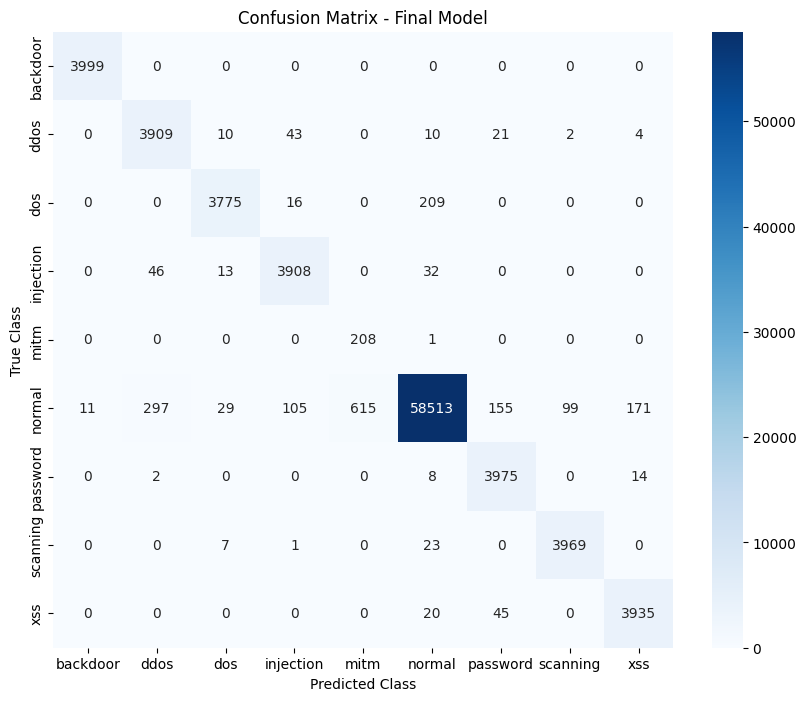

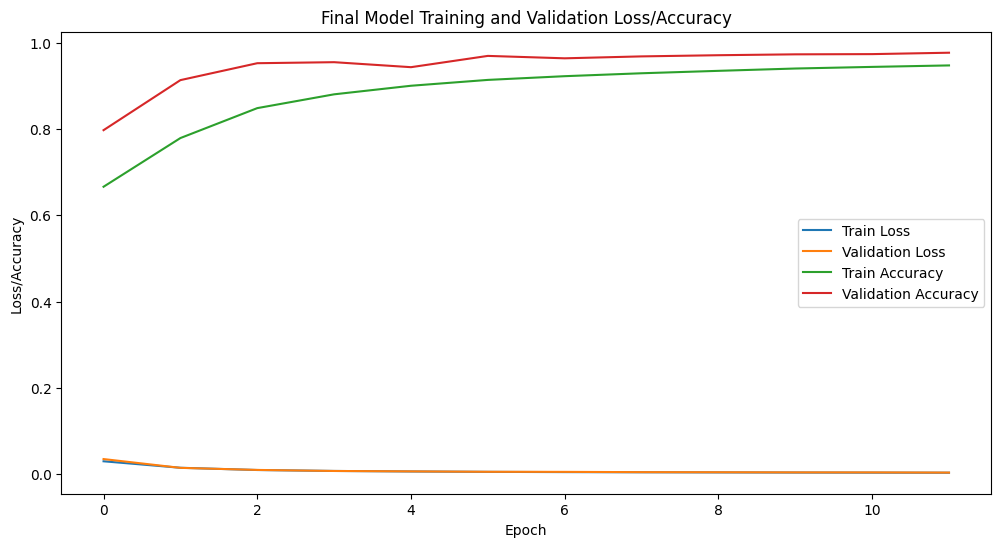

NameError: name 'precision_recall_curve' is not defined

<Figure size 800x600 with 0 Axes>

In [9]:
# Build and train the final model with best hyperparameters
final_model = tuner.hypermodel.build(best_hp)
history_final = final_model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=12,
    batch_size=64,
    shuffle=False,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

# Final evaluation on test set
results_final = final_model.evaluate(X_test_seq, y_test_seq, verbose=2)
print("Test Loss (Final):", results_final[0])
print("Test Accuracy (Final):", results_final[1])

# Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
y_pred_probs_final = final_model.predict(X_test_seq)
y_pred_classes_final = y_pred_probs_final.argmax(axis=1)
y_true_classes_final = y_test_seq.argmax(axis=1)
print(classification_report(y_true_classes_final, y_pred_classes_final))

import matplotlib.pyplot as plt
import seaborn as sns
cm_final = confusion_matrix(y_true_classes_final, y_pred_classes_final)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_,
            yticklabels=type_encoder.classes_)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix - Final Model')
plt.show()

# Training/Validation loss & accuracy curves
plt.figure(figsize=(12, 6))
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model Training and Validation Loss/Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()


# precision-recall curve for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    precision_i, recall_i, _ = precision_recall_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, label=f'Class {type_encoder.classes_[i]}')
plt.title('Multi-class Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.legend()
plt.show()

# gmean history
# plt.figure(figsize=(12, 6))
# plt.plot(history_final.history['multi_class_gmean'], label='Train G-Mean')
# plt.plot(history_final.history['val_multi_class_gmean'], label='Validation G-Mean')
# plt.title('Final Model Training and Validation G-Mean')
# plt.xlabel('Epoch')
# plt.ylabel('G-Mean')
# plt.legend()
# plt.show()


/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/12
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 340s 72ms/step - accuracy: 0.8643 - custom_objective: -240.2521 - loss: 0.0228 - multi_class_gmean: 0.8402 - precision_4: 0.9303 - recall_4: 0.8027 - val_accuracy: 0.9715 - val_custom_objective: -28.6324 - val_loss: 0.0124 - val_multi_class_gmean: 0.9803 - val_precision_4: 0.9776 - val_recall_4: 0.9617
Epoch 2/12
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 332s 72ms/step - accuracy: 0.9467 - custom_objective: -80.2815 - loss: 0.0077 - multi_class_gmean: 0.9479 - precision_4: 0.9589 - recall_4: 0.9330 - val_accuracy: 0.9805 - val_custom_objective: -19.1571 - val_loss: 0.0075 - val_multi_class_gmean: 0.9871 - val_precision_4: 0.9837 - val_recall_4: 0.9768
Epoch 3/12
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 332s 72ms/step - accuracy: 0.9543 - custom_objective: -67.8484 - loss: 0.0065 - multi_class_gmean: 0.9559 - precision_4: 0.9636 - recall_4: 0.9444 - val_accuracy: 0.9588 - val_custom_objective: -60.8401 - val_loss: 0.0111 - val_multi_class_gmean: 0.9584 - val_precisi

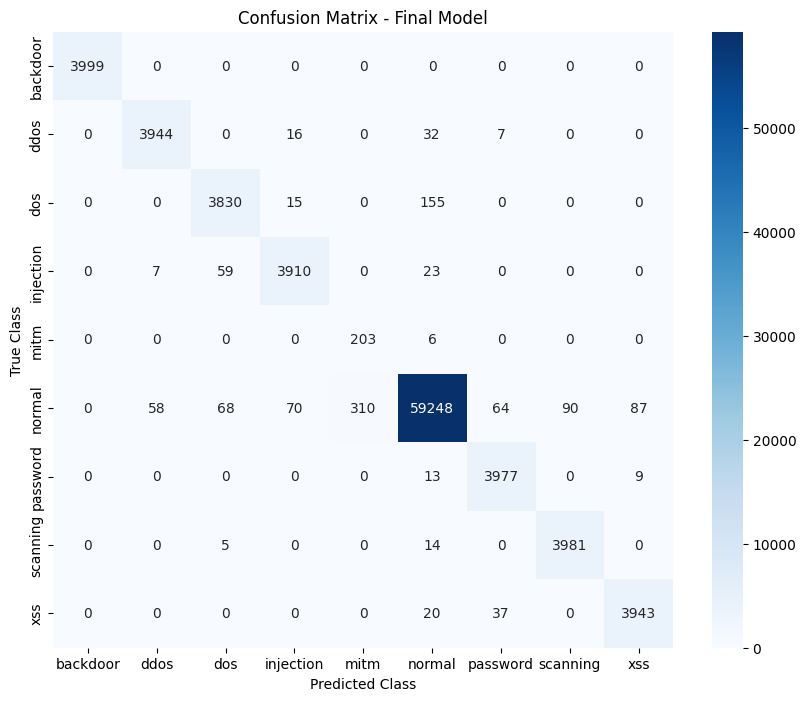

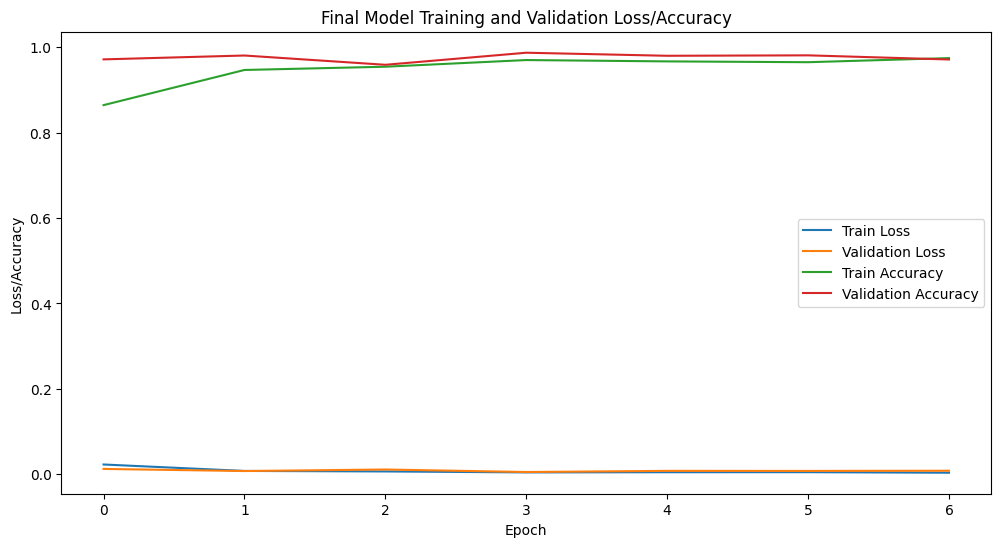

NameError: name 'precision_recall_curve' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
# Build and train the final model with best hyperparameters
final_model = tuner.hypermodel.build(best_hp)
history_final = final_model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=12,
    batch_size=64,
    shuffle=False, #TODO: need to be in False
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

# Final evaluation on test set
results_final = final_model.evaluate(X_test_seq, y_test_seq, verbose=2)
print("Test Loss (Final):", results_final[0])
print("Test Accuracy (Final):", results_final[1])

# Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
y_pred_probs_final = final_model.predict(X_test_seq)
y_pred_classes_final = y_pred_probs_final.argmax(axis=1)
y_true_classes_final = y_test_seq.argmax(axis=1)
print(classification_report(y_true_classes_final, y_pred_classes_final))

import matplotlib.pyplot as plt
import seaborn as sns
cm_final = confusion_matrix(y_true_classes_final, y_pred_classes_final)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_,
            yticklabels=type_encoder.classes_)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix - Final Model')
plt.show()

# Training/Validation loss & accuracy curves
plt.figure(figsize=(12, 6))
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model Training and Validation Loss/Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()


# precision-recall curve for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    precision_i, recall_i, _ = precision_recall_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, label=f'Class {type_encoder.classes_[i]}')
plt.title('Multi-class Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.legend()
plt.show()

# gmean history
plt.figure(figsize=(12, 6))
plt.plot(history_final.history['multi_class_gmean'], label='Train G-Mean')
plt.plot(history_final.history['val_multi_class_gmean'], label='Validation G-Mean')
plt.title('Final Model Training and Validation G-Mean')
plt.xlabel('Epoch')
plt.ylabel('G-Mean')
plt.legend()
plt.show()
